In [2]:
# Choosing optimal k for K-Means: Elbow Method + Silhouette Score
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Create synthetic clustering data
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)


# 2) Compute metrics for different k values
k_values = range(2, 15)

wcss = []        # Within-Cluster Sum of Squares (Elbow Method)
sil_scores = [] # Silhouette Scores

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    # Elbow metric
    wcss.append(kmeans.inertia_)

    # Silhouette metric
    sil_scores.append(silhouette_score(X, labels))

wcss

[9416.214004352274,
 2110.412521895329,
 564.9141808210252,
 512.3903339109634,
 460.3079031235534,
 408.9473812641575,
 360.82143438776376,
 325.372688355219,
 291.56086241067754,
 261.1127818951174,
 233.76574185504245,
 219.54751709728285,
 203.65412799725826]

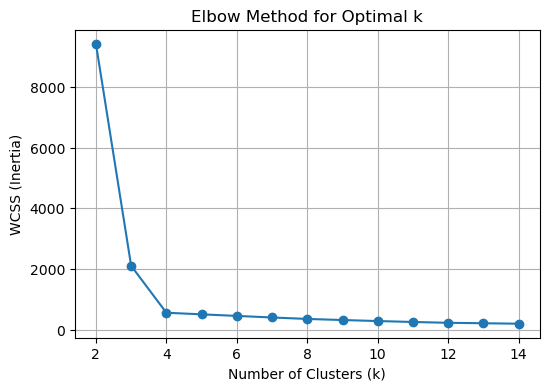

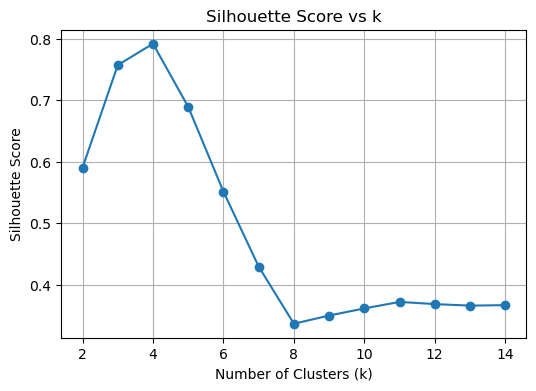

In [3]:
# plot elbow method
plt.figure(figsize=(6,4))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


# plot Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True)
plt.show()

In [4]:
# best k by Silhouette
best_k = k_values[np.argmax(sil_scores)]
print(f"Best k according to Silhouette Score: {best_k}")

Best k according to Silhouette Score: 4
